<a href="https://colab.research.google.com/github/AnnJohn05/Sales-Insights-Data-Analysis-Project/blob/main/Python_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Load Dataset
df = pd.read_csv("https://raw.githubusercontent.com/YBIFoundation/ProjectDataSet/refs/heads/main/Marketing%20Data%20Analysis.csv")
df.head()

,Unnamed: 0,Date,Channel,Region,Ad_Spend,Impressions,Clicks,Conversions,Revenue,CTR,Conversion_Rate
0,0,2025-01-01,Facebook,East,35072,324422,12194,1177,487278,4,10
1,1,2025-01-01,YouTube,North,15612,434523,5654,2927,2517220,1,52
2,2,2025-01-01,Instagram,East,5582,65898,9991,761,318859,15,8
3,3,2025-01-02,YouTube,East,21320,105984,7077,2505,2367225,7,35
4,4,2025-01-04,YouTube,South,10838,298801,16150,2179,1717052,5,13


In [ ]:
#Dataset Information
print("Shape of Dataset:", df.shape)
df.info()

Shape of Dataset: (1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       1000 non-null   int64 
 1   Date             1000 non-null   object
 2   Channel          1000 non-null   object
 3   Region           1000 non-null   object
 4   Ad_Spend         1000 non-null   int64 
 5   Impressions      1000 non-null   int64 
 6   Clicks           1000 non-null   int64 
 7   Conversions      1000 non-null   int64 
 8   Revenue          1000 non-null   int64 
 9   CTR              1000 non-null   int64 
 10  Conversion_Rate  1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [ ]:
#Check Missing Values
df.isnull().sum()

,0
Unnamed: 0,0
Date,0
Channel,0
Region,0
Ad_Spend,0
Impressions,0
Clicks,0
Conversions,0
Revenue,0
CTR,0


In [ ]:
#Statistical Summary
df.describe()

,Unnamed: 0,Ad_Spend,Impressions,Clicks,Conversions,Revenue,CTR,Conversion_Rate
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,499.500000,27373.362000,263305.952000,10205.10800,1520.087000,9.165629e+05,7.749000,28.621000
std,288.819436,12908.653881,139791.528738,5741.32884,862.106435,6.606403e+05,13.752714,43.401671
min,0.000000,5102.000000,10748.000000,533.00000,54.000000,1.956000e+04,0.000000,0.000000
25%,249.750000,16286.000000,147697.000000,5090.25000,791.750000,3.845415e+05,2.000000,7.750000
50%,499.500000,27914.500000,266647.000000,10208.50000,1475.000000,7.477765e+05,4.000000,15.000000
75%,749.250000,38630.000000,382078.250000,15254.75000,2262.000000,1.301754e+06,7.000000,29.000000
max,999.000000,49930.000000,499747.000000,19982.00000,2998.000000,2.810090e+06,151.000000,464.000000


In [ ]:
df.columns

Index(['Unnamed: 0', 'Date', 'Channel', 'Region', 'Ad_Spend', 'Impressions',
       'Clicks', 'Conversions', 'Revenue', 'CTR', 'Conversion_Rate'],
      dtype='object')

Channel
Email         203807018
Facebook      187586332
Google Ads    188713791
Instagram     162974026
YouTube       173481734
Name: Revenue, dtype: int64


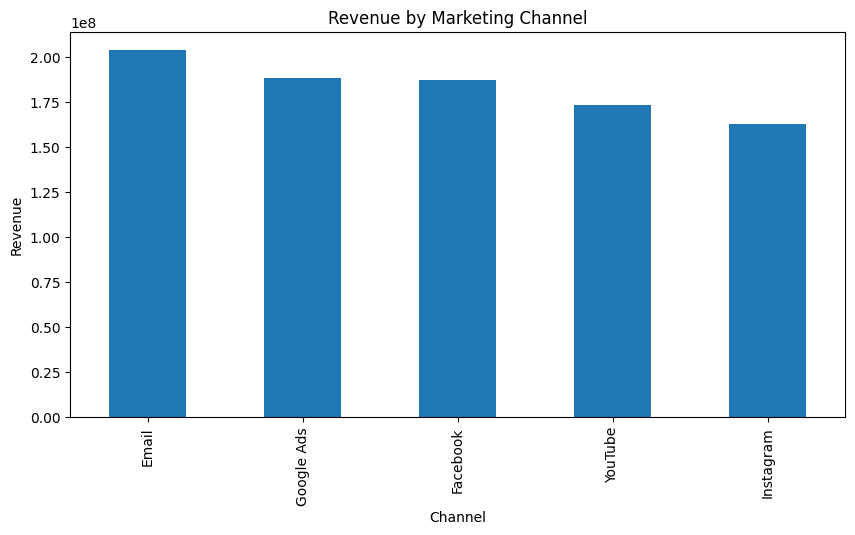

In [ ]:
#Highest Sales Campaigns
sales_by_channel = df.groupby('Channel')['Revenue'].sum()
print(sales_by_channel)
sales_by_channel.sort_values(ascending=False).plot(kind='bar', title='Revenue by Marketing Channel')
plt.ylabel("Revenue")
plt.show()

Channel
Email         7.948188
Facebook      9.529207
Google Ads    8.513322
Instagram     6.928171
YouTube       5.958567
Name: CTR, dtype: float64


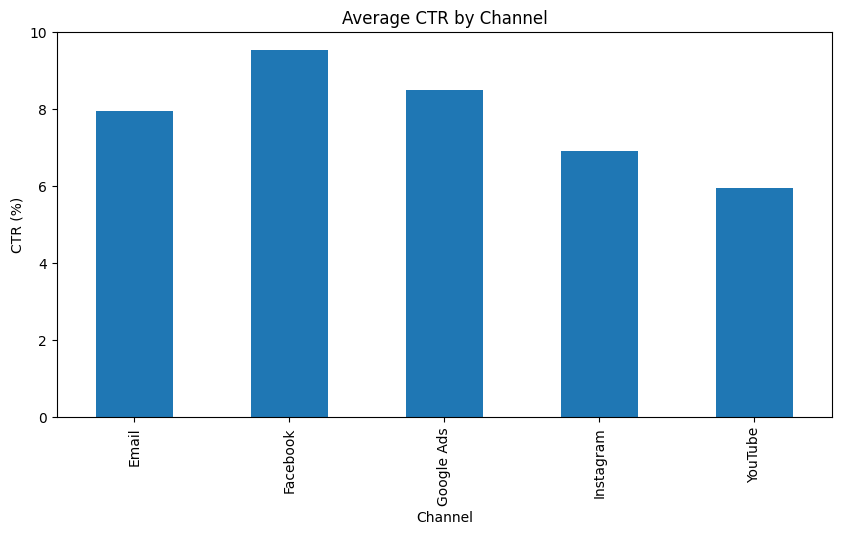

In [ ]:
#Customer Engagement Analysis
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100
engagement = df.groupby('Channel')['CTR'].mean()
print(engagement)
engagement.plot(kind='bar', title='Average CTR by Channel')
plt.ylabel("CTR (%)")
plt.show()

Channel
Email         29.683692
Facebook      27.199045
Google Ads    28.446192
Instagram     30.985273
YouTube       26.822683
Name: Conversion_Rate, dtype: float64


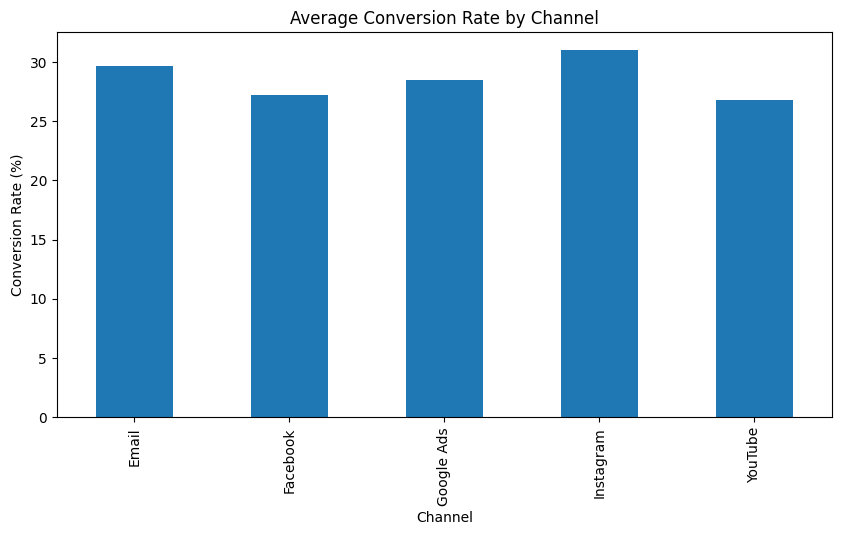

In [ ]:
#Conversion Rate Analysis
df['Conversion_Rate'] = (df['Conversions'] / df['Clicks']) * 100
conversion_rate = df.groupby('Channel')['Conversion_Rate'].mean()
print(conversion_rate)
conversion_rate.plot(kind='bar', title='Average Conversion Rate by Channel')
plt.ylabel("Conversion Rate (%)")
plt.show()

Channel
Email         48.093999
Facebook      46.315772
Google Ads    52.934882
Instagram     39.884954
YouTube       45.972493
Name: ROAS, dtype: float64


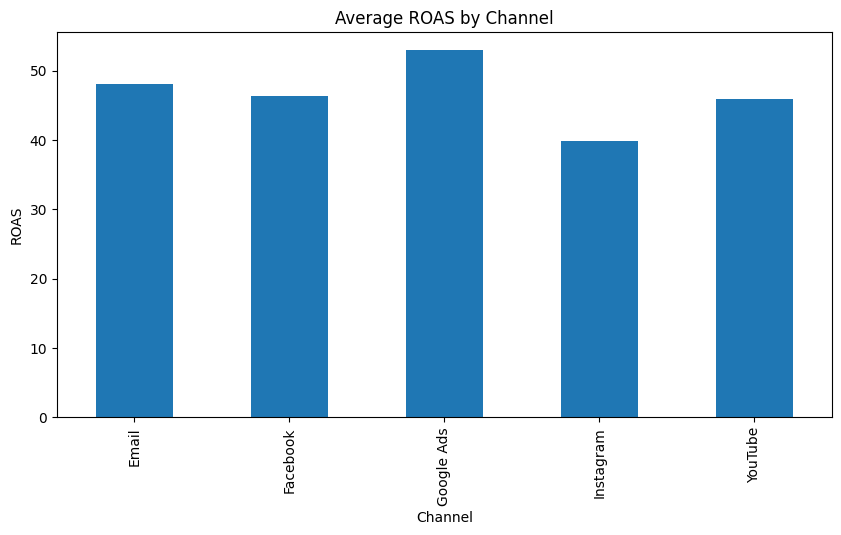

In [ ]:
#Return on Advertising Spend (ROAS)
df['ROAS'] = df['Revenue'] / df['Ad_Spend']
roas = df.groupby('Channel')['ROAS'].mean()
print(roas)
roas.plot(kind='bar', title='Average ROAS by Channel')
plt.ylabel("ROAS")
plt.show()

Month
2025-01    121509
2025-02    123460
2025-03    127037
2025-04    126557
2025-05    125330
2025-06    141115
2025-07    142137
2025-08    139391
2025-09    115175
2025-10    132860
2025-11    114666
2025-12    110850
Freq: M, Name: Conversions, dtype: int64


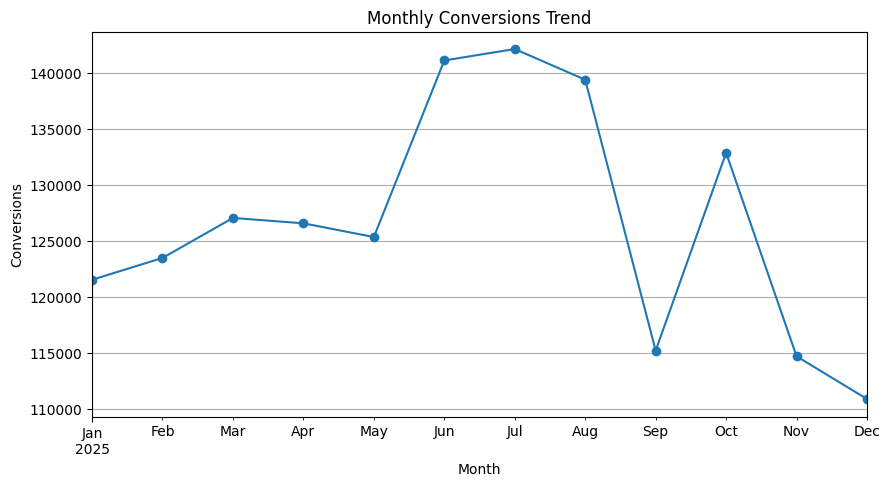

In [ ]:
#Monthly Growth in Conversions
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
monthly_conversion = df.groupby('Month')['Conversions'].sum()
print(monthly_conversion)
monthly_conversion.plot(marker='o',title='Monthly Conversions Trend')
plt.ylabel("Conversions")
plt.grid(True)
plt.show()

Channel
Email         203807018
Google Ads    188713791
Facebook      187586332
YouTube       173481734
Instagram     162974026
Name: Revenue, dtype: int64


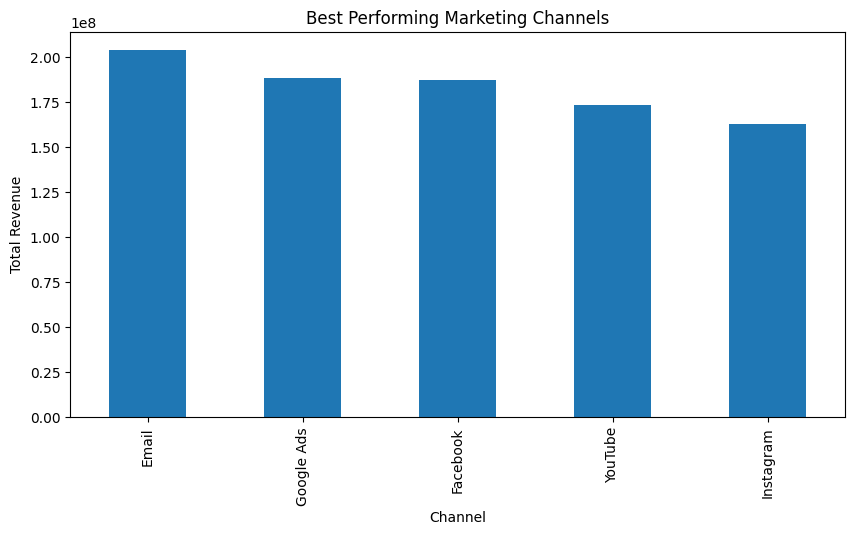

In [ ]:
#Best Performing Marketing Channel
best_channel = df.groupby('Channel')['Revenue'].sum().sort_values(ascending=False)
print(best_channel)
best_channel.plot(kind='bar',title='Best Performing Marketing Channels')
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
#Final Business Insights
print("BUSINESS INSIGHTS")
print("\nBest Revenue Channel:")
print(df.groupby('Channel')['Revenue'].sum().idxmax())
print("\nHighest Average ROAS:")
print(df.groupby('Channel')['ROAS'].mean().idxmax())
print("\nHighest CTR:")
print(df.groupby('Channel')['CTR'].mean().idxmax())
print("\nHighest Conversion Rate:")
print(df.groupby('Channel')['Conversion_Rate'].mean().idxmax())

BUSINESS INSIGHTS

Best Revenue Channel:
Email

Highest Average ROAS:
Google Ads

Highest CTR:
Facebook

Highest Conversion Rate:
Instagram
